In [51]:
%pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.


In [52]:
%pip install SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


In [53]:
%pip install load_dotenv

Note: you may need to restart the kernel to use updated packages.


In [54]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [55]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [56]:
%pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [57]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


# Set up database

In [58]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# SHOWER LOG

In [59]:
import pandas as pd

query = "SELECT * FROM SHOWER_LOG"
df = pd.read_sql(query, engine)

In [60]:
df.head()

,USER_ID,DAY_ID,SHOWER_START,SHOWER_DURING,SHOWER_TEMP
0,1,1,0 days 15:00:00,long,hot
1,1,2,0 days 13:00:00,long,hot
2,1,3,0 days 08:00:00,long,warm
3,1,3,0 days 20:30:00,short,hot
4,1,4,0 days 13:00:00,long,hot


In [61]:
print(df.describe())

       USER_ID     DAY_ID               SHOWER_START
count     10.0  10.000000                         10
mean       1.0   4.600000            0 days 13:03:00
std        0.0   2.366432  0 days 05:20:59.906541829
min        1.0   1.000000            0 days 06:15:00
25%        1.0   3.000000            0 days 09:15:00
50%        1.0   4.500000            0 days 13:00:00
75%        1.0   6.750000            0 days 14:37:30
max        1.0   8.000000            0 days 22:00:00


In [62]:
import matplotlib.pyplot as plt

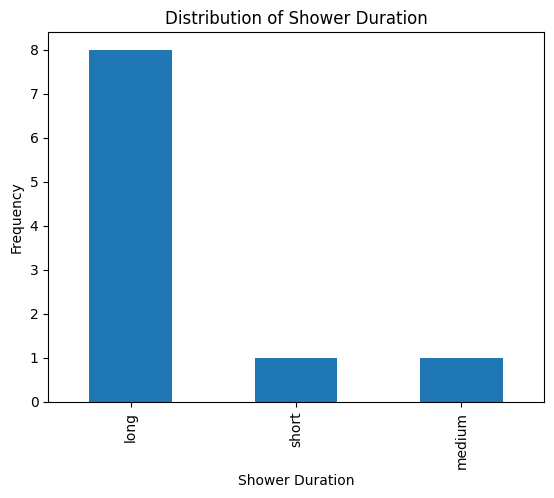

In [63]:
df['SHOWER_DURING'].value_counts().plot(kind='bar')
import matplotlib.pyplot as plt
plt.xlabel("Shower Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Shower Duration")
plt.show()

# PHONE SCREEN

In [64]:
query = "SELECT `DAY`, `SCREEN_TIME`, `SOCIAL` FROM `SAMSUNG_PHONE_SCREEN` NATURAL JOIN `DAY`"
ps = pd.read_sql(query, engine)

In [65]:
ps.head()

,DAY,SCREEN_TIME,SOCIAL
0,2025-06-20,399.0,353.0
1,2025-06-21,226.0,117.0
2,2025-06-22,274.0,195.0
3,2025-06-23,300.0,206.0
4,2025-06-24,123.0,113.0


In [66]:
print(ps[['SCREEN_TIME','SOCIAL']].describe())

       SCREEN_TIME      SOCIAL
count      7.00000    7.000000
mean     267.00000  170.285714
std       84.46301   91.670996
min      123.00000   93.000000
25%      235.00000  114.000000
50%      274.00000  117.000000
75%      301.50000  200.500000
max      399.00000  353.000000


<function matplotlib.pyplot.show(close=None, block=None)>

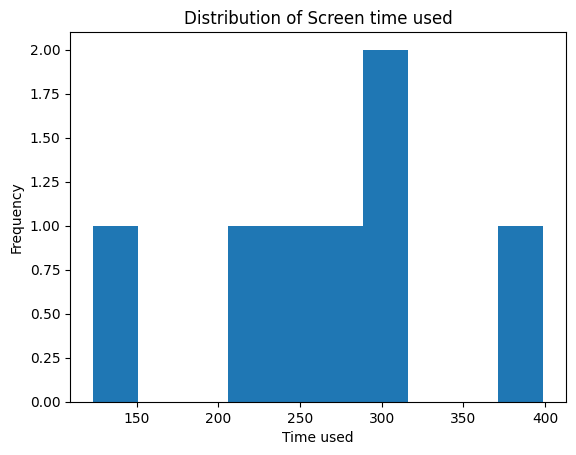

In [67]:
ps['SCREEN_TIME'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

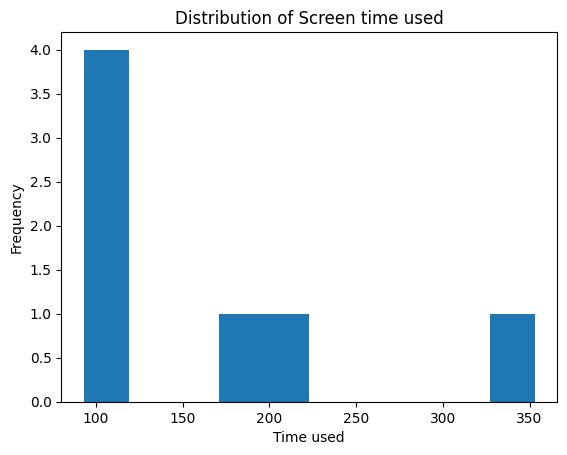

In [68]:
ps['SOCIAL'].plot.hist()
plt.xlabel("Time used")
plt.title("Distribution of Screen time used")
plt.show

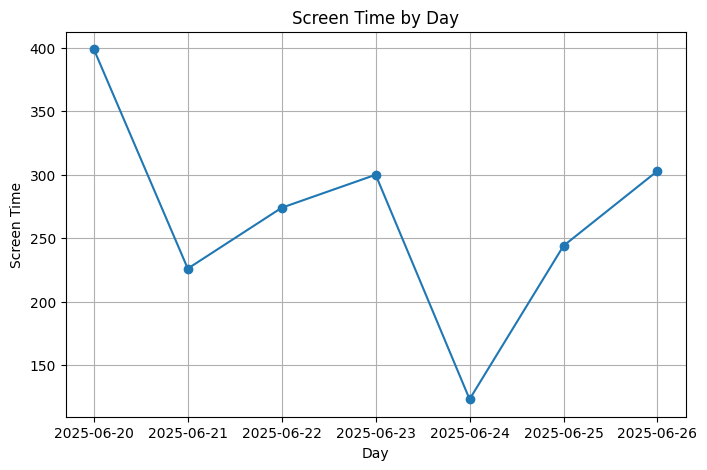

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SCREEN_TIME'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day')
plt.grid(True)
plt.show()

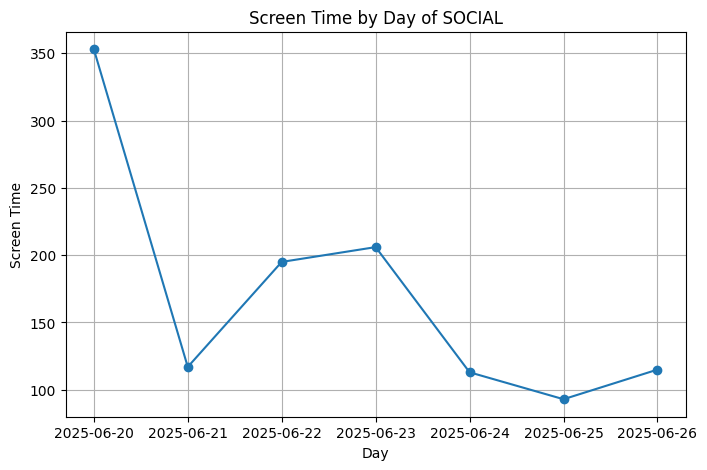

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(ps['DAY'], ps['SOCIAL'], marker='o')
plt.xlabel('Day')
plt.ylabel('Screen Time')
plt.title('Screen Time by Day of SOCIAL')
plt.grid(True)
plt.show()

$z$-score

In [71]:
from scipy.stats import zscore

ps['z_score of SCREEN_TIME'] = zscore(ps['SCREEN_TIME'])
ps['z_score of SOCIAL'] = zscore(ps['SOCIAL'])

ps.head()

,DAY,SCREEN_TIME,SOCIAL,z_score of SCREEN_TIME,z_score of SOCIAL
0,2025-06-20,399.0,353.0,1.688032,2.152851
1,2025-06-21,226.0,117.0,-0.524313,-0.627845
2,2025-06-22,274.0,195.0,0.089517,0.291199
3,2025-06-23,300.0,206.0,0.422008,0.420807
4,2025-06-24,123.0,113.0,-1.841490,-0.674975


Chebyshev's theorem

In [72]:
z = 1.6634959668526281
print(1-(1/(z*z)))

0.6386263390044107
